# Stage 3 Predictive Modeling: ANN Customer Churn Prediction

This notebook builds, trains, evaluates, and saves an Artificial Neural Network (ANN) model for predicting customer churn.

## Stage 3 Deliverables Covered

1. Defined architecture of the ANN model  
2. Trained ANN model on the prepared dataset  
3. Predicted customer churn and evaluated model performance

## 1. Import Required Libraries

This notebook uses pandas and numpy for data handling, scikit-learn for evaluation, matplotlib for graphs, and TensorFlow/Keras for building the ANN model.

In [201]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 2. Load Processed and Scaled Dataset

This model uses the processed train and test datasets created during Stage 2.

Important: The paths below assume this notebook is inside the `Stage_3_Predictive_Modeling` folder.

In [202]:
train_path = "../Data_Preparation/data/processed/churn_train.csv"
test_path = "../Data_Preparation/data/processed/churn_test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Training dataset shape:", train_df.shape)
print("Testing dataset shape:", test_df.shape)

train_df.head()

Training dataset shape: (5634, 11)
Testing dataset shape: (1409, 11)


,seniorcitizen,tenure,monthlycharges,gender_male,dependents_yes,phoneservice_yes,multiplelines_yes,internetservice_fiber optic,contract_one year,contract_two year,churn
0,0,1,60,1,1,1,0,0,0,1,0
1,0,30,55,0,0,1,0,0,1,0,0
2,1,46,100,0,0,1,1,1,0,0,0
3,0,43,66,1,0,1,0,0,1,0,0
4,0,1,20,1,0,1,1,1,0,1,0


## 3. Separate Features and Target Variable

The target variable is `churn`.

- `X_train` and `X_test` contain customer attributes.
- `y_train` and `y_test` contain the actual churn labels.

In [203]:
target_col = "churn"

if target_col not in train_df.columns:
    raise ValueError(f"Target column '{target_col}' not found in training dataset.")

if target_col not in test_df.columns:
    raise ValueError(f"Target column '{target_col}' not found in testing dataset.")

X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]

X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]

input_dim = X_train.shape[1]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Number of input features:", input_dim)
print("Target distribution in training data:")
print(y_train.value_counts(normalize=True))

X_train shape: (5634, 10)
X_test shape: (1409, 10)
Number of input features: 10
Target distribution in training data:
churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64


## 4. Define ANN Model Architecture

The ANN architecture includes:

| Layer | Configuration | Purpose |
|---|---|---|
| Input layer | Number of neurons equals number of input features | Accepts processed customer attributes |
| Hidden layer 1 | 64 neurons, ReLU activation | Learns broad customer churn patterns |
| Dropout | 0.30 | Reduces overfitting |
| Hidden layer 2 | 32 neurons, ReLU activation | Learns deeper non-linear relationships |
| Dropout | 0.20 | Improves generalisation |
| Hidden layer 3 | 16 neurons, ReLU activation | Refines learned patterns |
| Output layer | 1 neuron, sigmoid activation | Predicts churn probability |

The sigmoid output is suitable because churn prediction is a binary classification problem.

In [204]:
model = Sequential([
    Dense(64, activation="relu", input_shape=(input_dim,)),
    Dropout(0.30),

    Dense(32, activation="relu"),
    Dropout(0.20),

    Dense(16, activation="relu"),

    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/Users/subzzzzzzzzzzzs/Subin/telecom-churn-data-engineering/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_52 (Dense)                │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

Class Weight

In [205]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = {
    0: class_weights[0],
    1: class_weights[1]
}

print(class_weight_dict)

{0: np.float64(0.6805991785455424), 1: np.float64(1.8842809364548494)}


## 5. Train the ANN Model

The model is trained using:

- Adam optimiser for efficient learning
- Binary cross-entropy loss because churn is a binary target
- Early stopping to reduce overfitting and restore the best model weights

In [206]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 953us/step - accuracy: 0.5926 - loss: 1.1916 - val_accuracy: 0.7933 - val_loss: 0.5374
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 459us/step - accuracy: 0.6168 - loss: 0.7280 - val_accuracy: 0.7267 - val_loss: 0.5722
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 449us/step - accuracy: 0.6439 - loss: 0.6493 - val_accuracy: 0.7338 - val_loss: 0.5510
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 447us/step - accuracy: 0.6665 - loss: 0.6113 - val_accuracy: 0.7161 - val_loss: 0.5693
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 448us/step - accuracy: 0.6752 - loss: 0.5891 - val_accuracy: 0.7258 - val_loss: 0.5598
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 448us/step - accuracy: 0.6860 - loss: 0.5831 - val_accuracy: 0.7320 - val_loss: 0.5241
Epoch 7/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 446us/step - accuracy: 0.6829 - loss: 0.5864 - val_accuracy: 0.7187 - val_loss: 0.5424
Epoch 8/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 449us/step - accuracy: 0.7014 - loss: 0

## 6. Plot Training and Validation Performance

These graphs help check whether the ANN model is learning properly or overfitting.

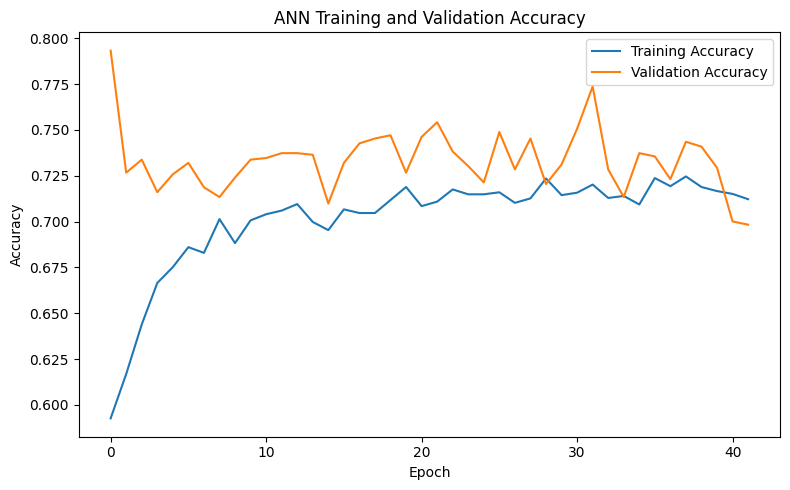

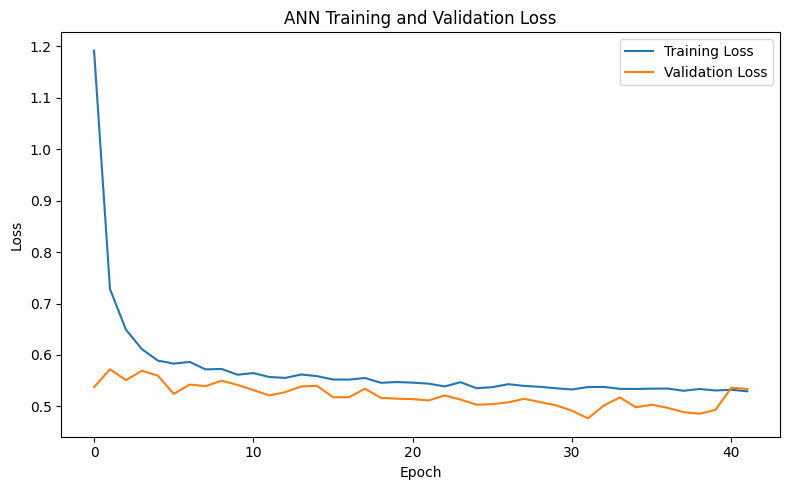

In [207]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("ANN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("ANN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Predict Customer Churn

The ANN outputs churn probabilities between 0 and 1.

A threshold of `0.5` is used:

- Probability >= 0.5 = churn
- Probability < 0.5 = no churn

In [208]:
y_prob = model.predict(X_test).ravel()
y_pred = (y_prob >= 0.5).astype(int)

prediction_preview = pd.DataFrame({
    "actual_churn": y_test.values,
    "predicted_churn": y_pred,
    "churn_probability": y_prob
})

prediction_preview.head(10)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 585us/step


,actual_churn,predicted_churn,churn_probability
0,0,1,0.790830
1,0,0,0.478331
2,0,0,0.051040
3,0,0,0.146963
4,0,0,0.199263
5,0,0,0.328232
6,0,0,0.028117
7,0,1,0.536673
8,0,0,0.221117
9,1,0,0.471071


## 8. Evaluate Model Performance

The model is evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion matrix

For churn prediction, recall is especially important because the business wants to identify customers who are likely to leave.

In [209]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Score": [accuracy, precision, recall, f1, roc_auc]
})

metrics_df

,Metric,Score
0,Accuracy,0.750177
1,Precision,0.523810
2,Recall,0.647059
3,F1-score,0.578947
4,ROC-AUC,0.802800


In [210]:
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.79      0.82      1035
           1       0.52      0.65      0.58       374

    accuracy                           0.75      1409
   macro avg       0.69      0.72      0.70      1409
weighted avg       0.77      0.75      0.76      1409



## 9. Confusion Matrix

The confusion matrix shows:

- True negatives: correctly predicted non-churn customers
- False positives: non-churn customers wrongly predicted as churn
- False negatives: churn customers missed by the model
- True positives: correctly predicted churn customers

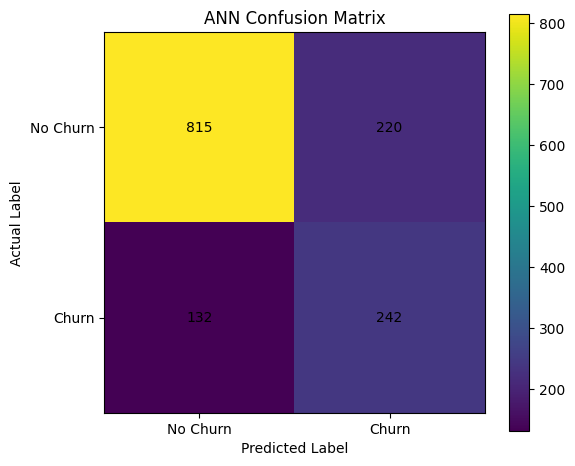

array([[815, 220],
       [132, 242]])

In [211]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("ANN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks([0, 1], ["No Churn", "Churn"])
plt.yticks([0, 1], ["No Churn", "Churn"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

cm

## 10. ROC Curve

The ROC curve shows how well the model separates churn and non-churn customers across different thresholds.

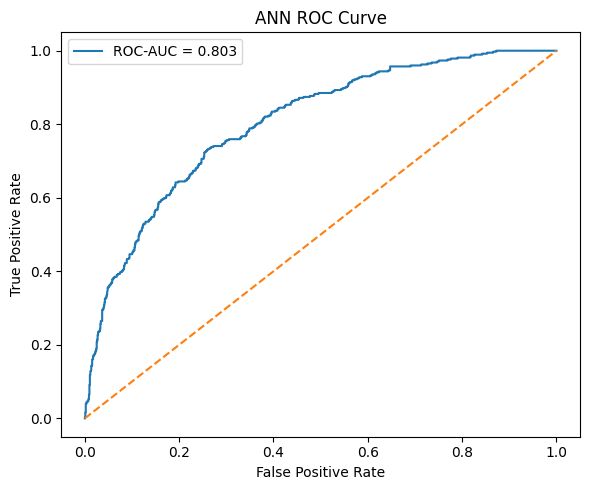

In [212]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ANN ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

## 11. Save Model, Metrics, Visualisations, and Predictions

This section creates output files required for Stage 3 evidence.

In [213]:
os.makedirs("saved_model", exist_ok=True)
os.makedirs("evaluation_results", exist_ok=True)
os.makedirs("predictions", exist_ok=True)

# Save trained model
model.save("saved_model/ann_churn_model.keras")

# Save metrics
metrics_df.to_csv("evaluation_results/model_metrics.csv", index=False)

# Save predictions
predictions_df = X_test.copy()
predictions_df["actual_churn"] = y_test.values
predictions_df["predicted_churn"] = y_pred
predictions_df["churn_probability"] = y_prob

predictions_df.to_csv("predictions/churn_predictions.csv", index=False)

# Save confusion matrix image
plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("ANN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks([0, 1], ["No Churn", "Churn"])
plt.yticks([0, 1], ["No Churn", "Churn"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.savefig("evaluation_results/confusion_matrix.png")
plt.close()

# Save ROC curve image
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ANN ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig("evaluation_results/roc_curve.png")
plt.close()

print("Saved files:")
print("- saved_model/ann_churn_model.keras")
print("- evaluation_results/model_metrics.csv")
print("- evaluation_results/confusion_matrix.png")
print("- evaluation_results/roc_curve.png")
print("- predictions/churn_predictions.csv")

Saved files:
- saved_model/ann_churn_model.keras
- evaluation_results/model_metrics.csv
- evaluation_results/confusion_matrix.png
- evaluation_results/roc_curve.png
- predictions/churn_predictions.csv


In [214]:
actual_churn_count = y_test.sum()
actual_no_churn_count = len(y_test) - actual_churn_count

predicted_churn_count = y_pred.sum()
predicted_no_churn_count = len(y_pred) - predicted_churn_count

print("Actual churned customers:", actual_churn_count)
print("Actual non-churned customers:", actual_no_churn_count)

print("Predicted churned customers:", predicted_churn_count)
print("Predicted non-churned customers:", predicted_no_churn_count)

Actual churned customers: 374
Actual non-churned customers: 1035
Predicted churned customers: 462
Predicted non-churned customers: 947


In [215]:
print("Actual churn rate:", round(actual_churn_count / len(y_test) * 100, 2), "%")
print("Predicted churn rate:", round(predicted_churn_count / len(y_pred) * 100, 2), "%")

Actual churn rate: 26.54 %
Predicted churn rate: 32.79 %


In the test dataset, [actual number] customers actually churned. The ANN model predicted that [predicted number] customers would churn. This shows how closely the model’s churn predictions matched the actual churn behaviour.

ClassWeight


## 12. Interpretation for Report

The ANN model was used to predict customer churn from the processed and scaled customer dataset. The model used hidden layers with ReLU activation to learn non-linear relationships between customer attributes and churn behaviour. Dropout layers were added to reduce overfitting and improve generalisation.

The model was evaluated using accuracy, precision, recall, F1-score, ROC-AUC, and a confusion matrix. Accuracy shows the overall percentage of correct predictions. Precision shows how many customers predicted as churn were actually churn customers. Recall is especially important because it shows how many actual churn customers were successfully identified. The F1-score balances precision and recall, while ROC-AUC shows how well the model separates churn and non-churn customers.

In churn prediction, false negatives are particularly important because they represent customers who actually churned but were not identified by the model. These missed customers reduce the business value of the prediction system because they may not receive retention support.